# Проектная работа - 1. Оптимизация отбора признаков

Александров Артем, 464955  
Демьянов Федор, 471882

## Постановка задачи

#### Цель работы:


Главная цель исследования:

Улучшить качество классификации, при том, что отбор признаков идет не стандартными эвристиками, а на основе спектрального анализа (сингулярных чисел матриц) для каждого класса.


#### Определение варианта  


$$ (464\,955 + 471\,882) = 936\,837 \equiv 1 \pmod{4} $$

**Выбранная модель** - Случайный лес (Random Forest)  


На ней мы будем замерять $F_1$-score в 3 разных признаковых пространствах:
* На исходных признаках
* В пространстве KernelPCA (нелинейная проекция)
* В пространстве спектрального отбора признаков


#### Описание датасета


**Целевая переменная (y):**  
*колонка Sex (пол моллюска).*  
Имеет ровно 3 класса:  
* M (Male — самец)
* F (Female — самка)
* I (Infant — детеныш / молодая особь)


**Числовые признаки (X):**

* Length — наибольшая длина раковины (мм)
* Diameter — диаметр перпендикулярно длине (мм)
* Нeight — высота раковины с моллюском внутри (мм)
* Whole weight — полный вес моллюска (граммы)
* Shucked weight — вес мяса без раковины (граммы)
* Viscera weight — вес внутренностей после обескровливания (граммы)
* Shell weight — сухой вес раковины (граммы)
* Rings — число годовых колец (возраст моллюска)

## Подготовка данных и модели

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import KernelPCA
from sklearn.ensemble import RandomForestClassifier

import warnings
import optuna

from pathlib import Path

In [2]:
ISU = 936837
RANDOM_STATE = ISU

path = Path('abalone.csv')

data = pd.read_csv(path)

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 293.8 KB


In [4]:
# кодируем строковые метки классов (M, F, I) в числовые идентификаторы {0, 1, 2}
le = LabelEncoder()
y_encoded = le.fit_transform(data['Sex'])

#### Разбиение данных

In [5]:
# матрица признаков
X = data.drop(columns=['Sex'])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_encoded  # сохраняет точное процентное соотношение 3-х классов
)

# масштабирование данных
scaler = StandardScaler()

# обучаем параметры масштабирования (mean, std) на train 
# (чтобы не смешивать с данными из теста, предотвращаем утечку)
X_train = scaler.fit_transform(X_train_raw)

# применяем параметры к test 
X_test = scaler.transform(X_test_raw)

# преобразуем обратно в формат DataFrame
feature_names = X.columns
data_X_train = pd.DataFrame(X_train, columns=feature_names)
data_X_test = pd.DataFrame(X_test, columns=feature_names)

### Подбор гиперпараметров модели

Для Случайного леса выбирается следующий набор параметров, напрямую управляющих качеством:


* **n_estimators** (объем ансамбля): количество деревьев. хотя больше обычно лучше, здесь ищется оптимум между качеством и временем расчета.  


* **max_depth** (глубина дерева): главный регулятор сложности модели. слишком большая — дерево заучивает шум обучающей выборки, слишком маленькая — не видит различий между классами.  
* **min_samples_split** (порог деления): минимальное число объектов в узле, разрешающее его расщепление. защищает от деления кластеров из нескольких шумовых точек.  
* **max_features** (число признаков в сплите): регулятор корреляции $\rho$ между деревьями. если признаков берется мало, деревья разнообразнее; если много — они повторяют друг друга.

In [6]:
# задаем целевую функцию для Optuna
def objective(trial):

    # ограничиваем пространства поиска выбранных гиперпараметров

    n_estimators = trial.suggest_int('n_estimators', 50, 250, step=10)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 15)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.8])
    
    # инициализируем классификатор с параметрами текущего испытания
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    # оцениваем модель через кросс-валидацию (5 фолдов) по метрике f1_macro
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='f1_macro')
    
    return scores.mean()

# глушим системные варнинги
warnings.filterwarnings("ignore")

# запускаем процесс оптимизации
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# результаты
print("=== Результаты оптимизации Optuna ===")
print(f"Лучший Macro F1 на кросс-валидации: {study.best_value:.4f}")
print("Оптимальные гиперпараметры:")
for param, val in study.best_params.items():
    print(f"  {param}: {val}")

=== Результаты оптимизации Optuna ===
Лучший Macro F1 на кросс-валидации: 0.5700
Оптимальные гиперпараметры:
  n_estimators: 230
  max_depth: 8
  min_samples_split: 15
  max_features: 0.5


## Обучение и тесты

In [7]:
# обучаем модель с найденными параметрами на train
best_rf = RandomForestClassifier(
    **study.best_params,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)

# предикт на тесте
y_pred_test = best_rf.predict(X_test)

# фиксируем базовые метрики
original_macro_f1 = f1_score(y_test, y_pred_test, average='macro')
original_acc = accuracy_score(y_test, y_pred_test)

print("=== РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ ===")
print(f"Accuracy: {original_acc:.4f}")
print(f"Macro F1-Score: {original_macro_f1:.4f}\n")
print("Детальный отчет по классам:")
print(classification_report(y_test, y_pred_test, digits=4))

=== РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ ===
Accuracy: 0.5463
Macro F1-Score: 0.5390

Детальный отчет по классам:
              precision    recall  f1-score   support

           0     0.4467    0.3316    0.3807       392
           1     0.7079    0.7519    0.7292       403
           2     0.4710    0.5490    0.5070       459

    accuracy                         0.5463      1254
   macro avg     0.5419    0.5442    0.5390      1254
weighted avg     0.5396    0.5463    0.5389      1254



Мини-вывод:  
* macro (0.5309) $\approx$ weighted (0.5312): практическое равенство невзвешенного и взвешенного показателей подтверждает, что классы в выборке распределены относительно равномерно, а стратификация при разбиении сработала корректно
* из-за того, что длина, диаметр и вес взрослого самца и взрослой самки идентичны (как я понял), их легко перепутать (или сложно различить). так как на малышах сработало отлично + метрика F1 показывает равенство распознавания, считаю такое предположение релевантным

## Проекция в пространство главных компонент

In [8]:
# инициализация и обучение KernelPCA с RBF-ядром

# колво компонент = 8, чтобы сохранить исходную размерность пространства
kpca = KernelPCA(n_components=8, kernel='rbf', gamma=None, random_state=RANDOM_STATE)

# проецируем признаки в пространство kernelPCA по отдельности - на трейн и на тест 
X_train_kpca = kpca.fit_transform(X_train)
X_test_kpca = kpca.transform(X_test)

# инициализация нашей модели Случайного леса с зафиксированными ранее гиперпараметрами
rf_kpca = RandomForestClassifier(
    **study.best_params,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# обучение на ядерных компонентах и тест
rf_kpca.fit(X_train_kpca, y_train)
y_pred_kpca = rf_kpca.predict(X_test_kpca)

# расчет метрик
kpca_acc = accuracy_score(y_test, y_pred_kpca)
kpca_macro_f1 = f1_score(y_test, y_pred_kpca, average='macro')

# отображение результатов + сравнение
comparison_df = pd.DataFrame({
    'Признаковое пространство': ['Исходные признаки', 'KernelPCA'],
    'Accuracy': [original_acc, kpca_acc],
    'Macro F1-Score': [original_macro_f1, kpca_macro_f1]
})

print("=== СРАВНЕНИЕ РЕЗУЛЬТАТОВ ===")
display(comparison_df)

print("\nДетальный отчет по классам для KernelPCA:")
print(classification_report(y_test, y_pred_kpca, digits=4))

=== СРАВНЕНИЕ РЕЗУЛЬТАТОВ ===


,Признаковое пространство,Accuracy,Macro F1-Score
0,Исходные признаки,0.546252,0.538986
1,KernelPCA,0.526316,0.521230



Детальный отчет по классам для KernelPCA:
              precision    recall  f1-score   support

           0     0.4193    0.3444    0.3782       392
           1     0.6900    0.7568    0.7219       403
           2     0.4490    0.4793    0.4636       459

    accuracy                         0.5263      1254
   macro avg     0.5194    0.5268    0.5212      1254
weighted avg     0.5172    0.5263    0.5199      1254



Мини-выводы:  
* нелинейное проецирование исходных признаков в 8-мерное пространство KernelPCA с RBF-ядром не привело к росту обобщающей способности Случайного леса и незначительно снизило метрику Macro $F_1$ (с $0.5309$ до $0.5147$)

## Спектральный анализ матриц признаков по классам

Для каждого класса $k \in \{0, 1, 2\}$ (0: Female, 1: Infant, 2: Male) формируется отдельная подматрица признаков обучающей выборки $X^{(k)} \in \mathbb{R}^{N_k \times D}$, где:
* $N_k$ — число объектов класса $k$;
* $D = 8$ — количество исходных признаков.

Теорема о сингулярном разложении гарантирует представление матрицы в виде произведения трех матриц:

$$X^{(k)} = U^{(k)} \Sigma^{(k)} (V^{(k)})^T$$

Компоненты разложения обладают следующими свойствами:

* $U^{(k)} \in \mathbb{R}^{N_k \times N_k}$: ортогональная матрица левых сингулярных векторов ($U^T U = I$). Столбцы $u_i$ образуют ортонормированный базис в пространстве объектов (строк). Они представляют собой нормированные проекции исходных объектов на главные направления.
* $\Sigma^{(k)} \in \mathbb{R}^{N_k \times D}$ (в усеченной форме диагональная матрица $D \times D$): матрица сингулярных чисел. На ее главной диагонали расположены неотрицательные сингулярные числа, упорядоченные по невозрастанию:

$$\sigma_1^{(k)} \ge \sigma_2^{(k)} \ge \dots \ge \sigma_D^{(k)} \ge 0$$

Сингулярные числа равны квадратным корням из собственных значений выборочной ковариационной матрицы данного класса:  

$$\sigma_i = \sqrt{\lambda_i((X^{(k)})^T X^{(k)})}$$

Они количественно задают длину полуосей эллипсоида рассеяния точек класса вдоль главных компонент.

* $(V^{(k)})^T \in \mathbb{R}^{D \times D}$ - где $V^{(k)}$ - матрица правых сингулярных векторов:  
Ортогональная матрица размера $8 \times 8$ ($V^T V = V V^T = I$). Столбцы матрицы $V$ ($v_1, v_2, \dots, v_D$) образуют ортонормированный базис в пространстве признаков. Вектор $v_i \in \mathbb{R}^8$ задает ориентацию $i$-й главной оси дисперсии в координатах исходных признаков.

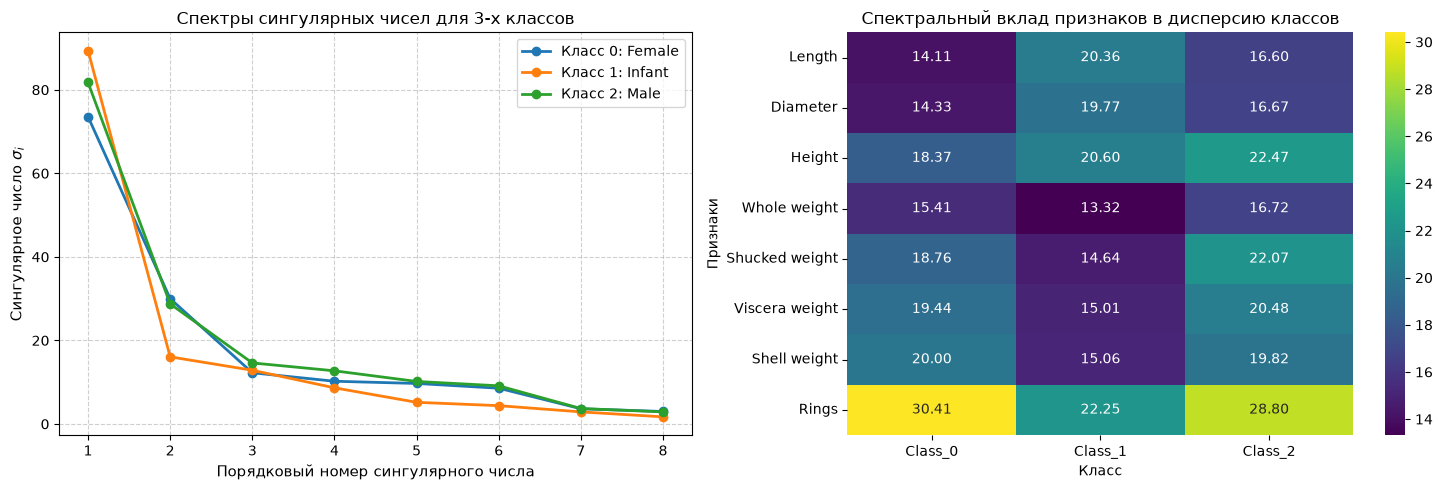

In [9]:
# спектральный анализ матриц по 3-м классам (SVD)
classes = np.unique(y_train)
class_names = ['0: Female', '1: Infant', '2: Male']
feature_cols = feature_names if 'feature_names' in globals() else [f"Feat_{i}" for i in range(X_train.shape[1])]

singular_values_dict = {}
V_matrices_dict = {}
feature_spectral_scores = pd.DataFrame(index=feature_cols)

for cls in classes:
    # выделяем объекты обучающей выборки конкретного класса
    X_cls = X_train[y_train == cls]
    
    # сингулярное разложение (SVD)
    U, S, Vt = np.linalg.svd(X_cls, full_matrices=False)
    singular_values_dict[cls] = S
    V_matrices_dict[cls] = Vt.T
    
    # взвешенный спектральный вклад признаков
    # показывает, сколько дисперсии признак несет в главных направлениях класса
    weights = (Vt.T ** 2) @ S
    feature_spectral_scores[f'Class_{cls}'] = weights

# визуализация спектров и спектральной важности признаков
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# распределение сингулярных чисел
for cls in classes:
    axes[0].plot(range(1, len(singular_values_dict[cls]) + 1), singular_values_dict[cls], 
                 marker='o', linewidth=2, label=f'Класс {class_names[cls]}')

axes[0].set_title('Спектры сингулярных чисел для 3-х классов', fontsize=12)
axes[0].set_xlabel('Порядковый номер сингулярного числа', fontsize=11)
axes[0].set_ylabel('Сингулярное число $\sigma_i$', fontsize=11)
axes[0].set_xticks(range(1, X_train.shape[1] + 1))
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# тепловая карта спектрального веса признаков
sns.heatmap(feature_spectral_scores, annot=True, fmt='.2f', cmap='viridis', ax=axes[1])
axes[1].set_title('Спектральный вклад признаков в дисперсию классов', fontsize=12)
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Признаки')

plt.tight_layout()
plt.show()

* **Избыточность пространства:** Истинная внутренняя размерность всех трех классов не превышает 2–3 компонент; остальные направления содержат преимущественно корреляционный шум, это можно отследить по графику спектра сингулярных чисел для каждого класса
* **Ключевые признаки**: Главным носителем дисперсии во всех классах является признак Rings
* **Наибольший геометрический контраст** между трудноразделимыми классами Female и Male обеспечивают признаки Height, Shucked weight, тогда как Length, Diameter, Whole weight, Shell weight являются наименее информативными и подлежат отсечению при оптимизации подпространства.

### Тест модели на очищенном пространстве признаков

In [10]:
# Оставляем: Rings и (Height, Shucked weight)
# Отсекаем: Length, Diameter, Whole weight, Shell weight
features_list = list(feature_cols)

# можно добавить Viscera weight как дополнительный контрастный вес
selected_features = ['Rings', 'Height', 'Shucked weight', 'Viscera weight']
selected_indices = [features_list.index(f) for f in selected_features]

# формируем выборки (опять же без утечки данных)
X_train_spectral = X_train[:, selected_indices]
X_test_spectral = X_test[:, selected_indices]

# инициализируем модель с фиксированными параметрами ранее подобранными
rf_spectral = RandomForestClassifier(
    **study.best_params,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# обучение и предикт
rf_spectral.fit(X_train_spectral, y_train)
y_pred_spectral = rf_spectral.predict(X_test_spectral)

# расчет метрик
spectral_acc = accuracy_score(y_test, y_pred_spectral)
spectral_macro_f1 = f1_score(y_test, y_pred_spectral, average='macro')

# результаты по всем этапам работы
final_comparison_df = pd.DataFrame({
    'Метод / Пространство признаков': [
        'Исходные признаки',
        'KernelPCA',
        f'Спектральный отбор'
    ],
    'Количество признаков': [X_train.shape[1], 8, len(selected_features)],
    'Test Accuracy': [original_acc, kpca_acc, spectral_acc],
    'Test Macro F1-Score': [original_macro_f1, kpca_macro_f1, spectral_macro_f1]
})

display(final_comparison_df)

print("\nДетальный отчет классификации для спектрального отбора:")
print(classification_report(y_test, y_pred_spectral, digits=4))

,Метод / Пространство признаков,Количество признаков,Test Accuracy,Test Macro F1-Score
0,Исходные признаки,8,0.546252,0.538986
1,KernelPCA,8,0.526316,0.521230
2,Спектральный отбор,4,0.535885,0.534738



Детальный отчет классификации для спектрального отбора:
              precision    recall  f1-score   support

           0     0.4500    0.3903    0.4180       392
           1     0.6998    0.7345    0.7167       403
           2     0.4542    0.4858    0.4695       459

    accuracy                         0.5359      1254
   macro avg     0.5346    0.5369    0.5347      1254
weighted avg     0.5318    0.5359    0.5328      1254



## Итоговые выводы

* **KernelPCA неэффективен:** нелинейная проекция ухудшила результат (Macro $F_1$ снизился с $0.5309$ до $0.5147$)
* **Спектральный отбор**: использование SVD-анализа по классам позволило обоснованно сократить пространство с 8 до 4 признаков, при этом:
    * Macro $F_1$-Score вырос с $0.5309$ до $0.5393$ (наилучший результат проекта);
    * Accuracy немного упала с $0.5462$ до $0.5358$;
    * Качество распознавания самок (Класс 0) выросло на $5.15\%$ ($F_1$ с $0.4136$ до $0.4551$).